<a href="https://colab.research.google.com/github/changyunyeong/MachineLearning_2026_01/blob/main/ML%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8_1%E1%84%8C%E1%85%AE%E1%84%8E%E1%85%A1_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 머신러닝 실습 1주차

---

# Part 1. Data Cleaning

현실 세계의 데이터는 불완전하고 노이즈가 많기 때문에 분석 전 정제 과정을 필요로 함

### ■ 결측치 3가지 유형
1. **MCAR (Missing Completely at Random):** 결측치가 발생한 것이 다른 어떤 변수와도 상관없이 완전히 무작위로 발생한 경우
2. **MAR (Missing at Random):** 결측치 발생이 관측된 다른 변수들에 의해 설명될 수 있는 경우
3. **MNAR (Missing Not at Random):** 결측치 발생이 관측되지 않은 변수와 연관이 있는 경우

### ■ 어떻게 처리할 것인가?
*   **제거 (Elimination):** 결측치가 있는 행이나 열을 아예 삭제 (데이터 손실)
*   **대체 (Imputation):**
    *   **전역 상수(Global Constant):** "Unknown"이나 0 등으로 일괄 채움
    *   **평균/중앙값/최빈값(Mean/Median/Most Frequent):** 계산이 빠르고 쉬움. 하지만 정확도가 떨어질 수 있음
    *   **추론 기반(Inference-based):** K-NN, 딥러닝 등을 사용해 값을 예측해서 채움. 정확하지만 높은 계산 비용



---



## ■ Toy example

In [3]:
import numpy as np
import pandas as pd

# 가상의 데이터 생성 (결측치 포함)
data = {'Age': [25, np.nan, 29, 31, np.nan, 26],
        'Salary': [5000, 6000, np.nan, 8000, 5500, 2200],
        'Department': ['CS', 'AI', 'Law', np.nan, 'AI', 'CS'] # 결측치 데이터 포함
        }

df = pd.DataFrame(data)

print("--- 원본 데이터 ---")
print(df)
print("\n")
display(df)


# 각 컬럼의 평균을 직접 계산해서 결측치 채우기
# 수치형 데이터
mean_age = df['Age'].mean()
mean_salary = df['Salary'].mean()

df_manual = df.copy()
df_manual['Age'] = df_manual['Age'].fillna(mean_age) # 0가능 # 자동으로 nan에 mean값 저장
df_manual['Salary'] = df_manual['Salary'].fillna(mean_salary)

print("\n\n --- Pandas 수작업으로 평균 채우기 ---")
print(df_manual)

# 범주형 데이터
mode_department = df['Department'].mode() # 부서는 범주형 데이터이므로 따로 결측값 채우기
print(f"\n최빈값:\n{mode_department}")

df_manual['Department'] = df_manual['Department'].fillna(mode_department[0]) # Unknown으로도 가능
display(df_manual)


--- 원본 데이터 ---
    Age  Salary Department
0  25.0  5000.0         CS
1   NaN  6000.0         AI
2  29.0     NaN        Law
3  31.0  8000.0        NaN
4   NaN  5500.0         AI
5  26.0  2200.0         CS




,Age,Salary,Department
0,25.0,5000.0,CS
1,NaN,6000.0,AI
2,29.0,NaN,Law
3,31.0,8000.0,NaN
4,NaN,5500.0,AI
5,26.0,2200.0,CS




 --- Pandas 수작업으로 평균 채우기 ---
     Age  Salary Department
0  25.00  5000.0         CS
1  27.75  6000.0         AI
2  29.00  5340.0        Law
3  31.00  8000.0        NaN
4  27.75  5500.0         AI
5  26.00  2200.0         CS

최빈값:
0    AI
1    CS
Name: Department, dtype: object


,Age,Salary,Department
0,25.00,5000.0,CS
1,27.75,6000.0,AI
2,29.00,5340.0,Law
3,31.00,8000.0,AI
4,27.75,5500.0,AI
5,26.00,2200.0,CS


## ■ Sklearn imputer 사용 예제

In [2]:
from sklearn.impute import SimpleImputer
### 오류 예시
# Scikit-learn의 SimpleImputer 사용
imputer = SimpleImputer(strategy='mean') # mean, median, most_frequent, constant, ...

# fit_transform으로 한 번에 학습 및 적용
df_sklearn = pd.DataFrame(imputer.fit_transform(df), columns=df.columns) # 범주형 변수는 mean 사용 불가

print("\n--- Scikit-learn으로 쉽게 처리하기 ---")
print(df_sklearn)

ValueError: Cannot use mean strategy with non-numeric data:
could not convert string to float: 'CS'

In [4]:
# 타입별 열 분류
num_cols = df.select_dtypes(include=np.number).columns # 수치형 데이터 포함
cat_cols = df.select_dtypes(exclude=np.number).columns # 비수치형 데이터 열외

print(num_cols)
print(cat_cols)

# 숫자형: 평균
num_imputer = SimpleImputer(strategy="mean") # 어떤 전략으로 채울 건지
df_num = pd.DataFrame(
    num_imputer.fit_transform(df[num_cols]),
    columns=num_cols
)

# 범주형: 최빈값
cat_imputer = SimpleImputer(strategy="most_frequent")
df_cat = pd.DataFrame(
    cat_imputer.fit_transform(df[cat_cols]),
    columns=cat_cols
)

# 다시 합치기
df_imputed = pd.concat([df_num, df_cat], axis=1)

# 원래 열 순서로 정렬
df_imputed = df_imputed[df.columns]

display(df_imputed)


Index(['Age', 'Salary'], dtype='object')
Index(['Department'], dtype='object')


,Age,Salary,Department
0,25.00,5000.0,CS
1,27.75,6000.0,AI
2,29.00,5340.0,Law
3,31.00,8000.0,AI
4,27.75,5500.0,AI
5,26.00,2200.0,CS


## ■ 실전 예제

In [5]:
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

# 타이타닉 데이터 불러오기
titanic = sns.load_dataset('titanic')
display(titanic)
print("=== 타이타닉 원본 결측치 개수 ===")
print(titanic[['age', 'embarked', 'deck']].isnull().sum())

# 실습을 위해 수치형(age)과 범주형(embarked) 컬럼만 추출
df_real = titanic[['age', 'embarked']].copy()

# 1. Scikit-learn의 SimpleImputer 사용
# 수치형: 평균(mean), 범주형: 최빈값(most_frequent)
num_cols = df_real.select_dtypes(include=np.number).columns
cat_cols = df_real.select_dtypes(exclude=np.number).columns

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

df_sklearn = df_real.copy()
df_sklearn['age'] = pd.DataFrame(imputer_num.fit_transform(df_sklearn[num_cols]), columns=num_cols)
df_sklearn['embarked'] = pd.DataFrame(imputer_cat.fit_transform(df_sklearn[cat_cols]), columns=cat_cols)

print("\n=== SimpleImputer 적용 후 결측치 개수 ===")
print(df_sklearn.isnull().sum())


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


=== 타이타닉 원본 결측치 개수 ===
age         177
embarked      2
deck        688
dtype: int64

=== SimpleImputer 적용 후 결측치 개수 ===
age         0
embarked    0
dtype: int64


## ■ 추론 기반 방법

In [6]:
# KNN Imputer 사용 (데이터의 패턴을 보고 유사한 값으로 채워 넣음)
knn_imputer = KNNImputer(n_neighbors=10)
df_knn = df_real.copy()
df_knn['age'] = knn_imputer.fit_transform(df_knn[['age']])

print("\n=== 원본의 Age, SimpleImputer(평균) Age, KNN Imputer Age 비교 (결측치였던 행 5번 확인) ===")

# 결과 비교
compare_df = pd.DataFrame({
    'Original': df_real['age'].head(10),
    'Mean_Imputed': df_sklearn['age'].head(10),
    'KNN_Imputed': df_knn['age'].head(10)
})
display(compare_df)


=== 원본의 Age, SimpleImputer(평균) Age, KNN Imputer Age 비교 (결측치였던 행 5번 확인) ===


,Original,Mean_Imputed,KNN_Imputed
0,22.0,22.0,22.000000
1,38.0,38.0,38.000000
2,26.0,26.0,26.000000
3,35.0,35.0,35.000000
4,35.0,35.0,35.000000
5,NaN,28.0,29.699118
6,54.0,54.0,54.000000
7,2.0,2.0,2.000000
8,27.0,27.0,27.000000
9,14.0,14.0,14.000000


-------

# Part 2. Data Integration

여러 데이터베이스나 파일을 하나로 통합할 때, 이름만 다르고 사실상 같은 정보를 담고 있는 중복이 발생하기 쉬움

(ex. 상품 가격과 결제 금액은 강한 연관성 존재)

### ■ 수치형 데이터: 공분산과 상관계수
*   **공분산 (Covariance, $Cov(A,B)$):** 두 변수가 각자의 평균으로부터 얼마나 함께 변하는지 측정
    *   $Cov(A,B) > 0$: 두 변수가 함께 증가 (Positive covariance)
    *   $Cov(A,B) < 0$: 한 변수가 증가할 때 다른 변수는 감소 (Negative covariance)

*   **피어슨 상관계수 (Pearson Correlation Coefficient, $r_{A,B}$):** 공분산을 각 변수의 표준편차로 나누어 -1과 1 사이의 값으로 정규화한 지표
    *   $r_{A,B} = \frac{Cov(A,B)}{\sigma_A \sigma_B}$

### ■ 범주형 데이터: 카이제곱 검정
*   **카이제곱($\chi^2$) 검정:** 두 범주형 변수(예: 성별, 취미)가 서로 독립적인지, 아니면 연관성이 있는지 확인
    *   수식: $\chi^2 = \sum \frac{(Observed - Expected)^2}{Expected}$

---

## ■ Toy example

In [7]:
###
# 공분산 및 상관계수

stock_data = {
    'Stock_A': [8, 9, 10, 11, 12],
    'Stock_B': [1, 2, 7, 10, 13]
}
df_stock = pd.DataFrame(stock_data)

print("=== 주식 A, B 데이터 ===")
display(df_stock)

# 1. 기대값(평균) 계산
mean_A = df_stock['Stock_A'].mean() # 4.0
mean_B = df_stock['Stock_B'].mean() # 9.6

# 2. 공분산 계산
# 공식: E(A*B) - E(A)*E(B)
E_AB = (df_stock['Stock_A'] * df_stock['Stock_B']).mean()
cov_manual = E_AB - (mean_A * mean_B)

print(f"\n A와 B의 공분산(Covariance): {cov_manual:.2f}")

# 3. 상관계수(Correlation)
# 공식: Cov(A,B) / (std_A * std_B)
std_A = df_stock['Stock_A'].std(ddof=0) # 모집단 표준편차 || 표본집단: ddof-1
std_B = df_stock['Stock_B'].std(ddof=0)
corr_manual = cov_manual / (std_A * std_B)

print(f"[수작업] 주식 A와 B의 상관계수(Correlation): {corr_manual:.4f}")


=== 주식 A, B 데이터 ===


,Stock_A,Stock_B
0,8,1
1,9,2
2,10,7
3,11,10
4,12,13



 A와 B의 공분산(Covariance): 6.40
[수작업] 주식 A와 B의 상관계수(Correlation): 0.9866


### ■ 카이제곱 검정

In [8]:
import numpy as np
from scipy.stats import chi2_contingency

table = np.array([
    [40, 60],
    [30, 70]
])

chi2, p, dof, expected = chi2_contingency(table)

# 귀무 가설 검정
print("Chi-square:", chi2)
print("p-value:", p)
print("dof:", dof)
print("Expected frequencies:\n", expected)
# p_value >= 0.05 채택, or 기각

Chi-square: 1.7802197802197803
p-value: 0.18212234100949087
dof: 1
Expected frequencies:
 [[35. 65.]
 [35. 65.]]



### ■ 실전 예제

=== Pandas .cov() (공분산 행렬) ===


,total_bill,tip
total_bill,79.252939,8.323502
tip,8.323502,1.914455



=== Pandas .corr() (상관계수 행렬) ===


,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


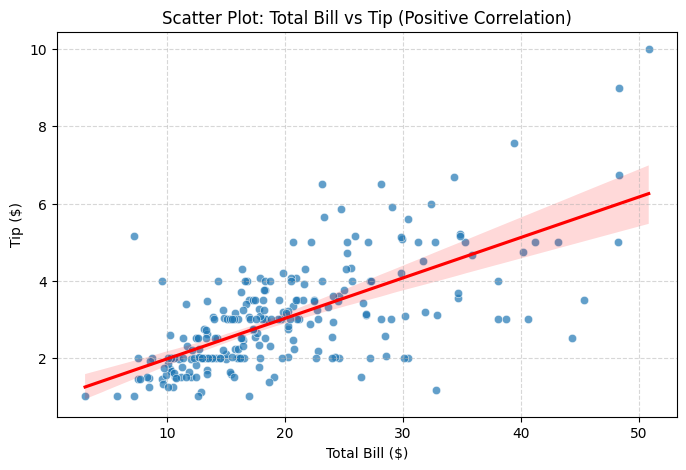

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터셋 불러오기 (식당 결제 금액 및 팁 데이터)
tips = sns.load_dataset('tips')
df_real = tips[['total_bill', 'tip']].copy()

# display(df_real)

# 1. Pandas 내장 함수 활용
print("=== Pandas .cov() (공분산 행렬) ===")
display(df_real.cov())

print("\n=== Pandas .corr() (상관계수 행렬) ===")
display(df_real.corr())

# 2. 산점도 시각화
plt.figure(figsize=(8, 5))
sns.scatterplot(x='total_bill', y='tip', data=df_real, alpha=0.7)

# 추세선 확인
sns.regplot(x='total_bill', y='tip', data=df_real, scatter=False, color='red')

plt.title('Scatter Plot: Total Bill vs Tip (Positive Correlation)')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---

# Part 3. Data Reduction

데이터가 너무 방대하면 분석과 모델링에 드는 비용이 크게 때문에, 데이터의 원래 특성을 최대한 보존하면서 크기를 줄이는 **데이터 축소**는 필수적임

### ■ 수량 축소 (Numerosity Reduction)
데이터의 양(Row, Tuple) 자체를 줄이는 방법
*   **단순 무작위 샘플링 (Simple Random Sampling):**
    *   비복원 추출: 한 번 뽑힌 데이터는 모집단에서 제거
    *   복원 추출: 한 번 뽑힌 데이터도 다시 모집단에 넣어, 중복 추출이 가능함
*   **층화 추출법 (Stratified Sampling):**
    * 데이터를 전체적으로 무작위로 뽑으면 특정 편향이 발생할 수 있음.
     
      따라서 데이터를 여러 계층으로 나눈 뒤 각 파티션의 비율에 맞게 무작위 추출을 진행함

### ■ 차원 축소 (Dimensionality Reduction)
변수(Feature, Column)의 개수를 줄이는 방법

변수가 너무 많아지면 데이터가 희소해지고 거리 계산이 무의미해지는 차원의 저주(Curse of dimensionality)가 생김
*   **속성 부분집합 선택 (Attribute Subset Selection):**
    * 분석에 무관하거나 중복되는 변수를 제거
*   **주성분 분석 (PCA - Principal Component Analysis):**
    * 여러 변수들의 정보를 압축하여, 원래 데이터의 분산을 최대한 보존하는 더 적은 수의 새로운 차원(변수)로 변경




### ■ Sampling

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns

# 데이터셋 불러오기 (붓꽃의 꽃받침, 꽃잎 길이/너비 데이터)
iris = sns.load_dataset('iris')

print(f"=== 원본 데이터 크기: {iris.shape} ===")
display(iris.head())

print("\n[원본 데이터의 종(Species)별 개수]")
print(iris['species'].value_counts())


# 샘플링
# 1. 단순 무작위 비복원 추출
# 전체 데이터 150개 중 무작위로 15개(10%)만 뽑음 (중복 불가)
sample_without_replacement = iris.sample(n=15, replace=False, random_state=42)
print("\n=== 1. 단순 무작위 비복원 추출 (15개) ===")
print(sample_without_replacement['species'].value_counts())

# 2. 단순 무작위 복원 추출
# 한 번 뽑힌 데이터가 또 뽑힐 수 있음
sample_with_replacement = iris.sample(n=15, replace=True, random_state=42)
print("\n=== 2. 단순 무작위 복원 추출 (15개) ===")
print(sample_with_replacement.head())

# 3. 층화 추출법 (Stratified Sampling)
# 위 추출 결과를 보면 종(species)별 개수가 균일하지 않음 -> 데이터 분석 잘 안 될 수도
# 층화 추출을 통해 원본 데이터의 종별 비율(1:1:1)을 똑같이 유지할 수 있음
stratified_sample = iris.groupby('species', group_keys=False).apply(lambda x: x.sample(n=5, random_state=42)) # 종 별로 데이터 나눔 -> 그룹 별 리스트에서 n개씩 추출

print("\n=== 3. 층화 추출 (각 파티션별로 5개씩 총 15개 추출) ===")
print(stratified_sample['species'].value_counts())

=== 원본 데이터 크기: (150, 5) ===


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



[원본 데이터의 종(Species)별 개수]
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

=== 1. 단순 무작위 비복원 추출 (15개) ===
species
versicolor    6
setosa        6
virginica     3
Name: count, dtype: int64

=== 2. 단순 무작위 복원 추출 (15개) ===
     sepal_length  sepal_width  petal_length  petal_width     species
102           7.1          3.0           5.9          2.1   virginica
92            5.8          2.6           4.0          1.2  versicolor
14            5.8          4.0           1.2          0.2      setosa
106           4.9          2.5           4.5          1.7   virginica
71            6.1          2.8           4.0          1.3  versicolor

=== 3. 층화 추출 (각 파티션별로 5개씩 총 15개 추출) ===
species
setosa        5
versicolor    5
virginica     5
Name: count, dtype: int64


/tmp/ipykernel_2580/3402862157.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = iris.groupby('species', group_keys=False).apply(lambda x: x.sample(n=5, random_state=42))


### ■ PCA

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 데이터셋 불러오기
iris = sns.load_dataset('iris')
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = iris[features]
y = iris['species']


# Scikit-learn의 PCA 모델 초기화
pca = PCA(n_components=2) # 2차원
X_pca = pca.fit_transform(X)

# 2차원으로 축소된 데이터를 Pandas DataFrame으로 변환
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['species'] = y

# 데이터 변환시킨 값으로 축소 (기존 데이터 그대로 가져온 게 아님)
# 기존보다 적은 데이터로 데이터의 특성 잘 파악할 수 있음

print("=== PCA 적용 후 데이터 (4차원 -> 2차원) ===")
display(pca_df.head())


=== PCA 적용 후 데이터 (4차원 -> 2차원) ===


,Principal Component 1,Principal Component 2,species
0,-2.684126,0.319397,setosa
1,-2.714142,-0.177001,setosa
2,-2.888991,-0.144949,setosa
3,-2.745343,-0.318299,setosa
4,-2.728717,0.326755,setosa


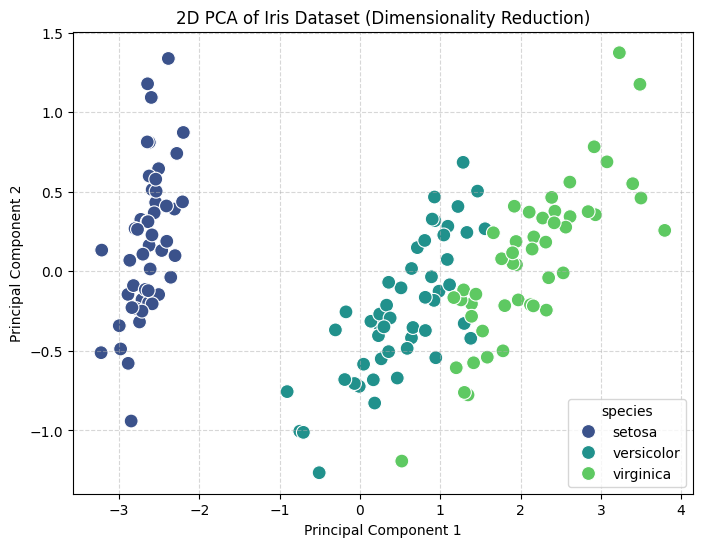

[0.92461872 0.05306648]


In [21]:
# mpl_toolkits.mplot3d : 3차원 데이터 시각화

# PCA 결과 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='species', data=pca_df, palette='viridis', s=100)
plt.title('2D PCA of Iris Dataset (Dimensionality Reduction)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 분산 설명력 확인
explained_variance = sum(pca.explained_variance_ratio_) * 100
print(pca.explained_variance_ratio_)

# 원본 데이터 보존하며 효율적으로 데이터 분석 가능

# tsne: 비선형 데이터라 pca 한계 극복 가능
# UMAP: 더 고차원의 데이터를 다루기 쉬움


---

# Part 4. Data Transformation

머신러닝 모델은 입력 데이터의 스케일(단위)에 매우 민감함. (ex. 나이, 연봉 상황에서 범위가 큰 연봉이 결과에 과도한 영향을 미치게 됨)

### ■ 정규화 (Normalization)
데이터 스케일 맞추기
*   **Min-max 정규화:** 데이터를 0과 1 사이(또는 지정된 범위)로 변환
    *   수식: $v' = \frac{v - min_A}{max_A - min_A}(new\_max_A - new\_min_A) + new\_min_A$
*   **Z-score 정규화 (표준화):** 데이터의 평균($\mu$)을 0, 표준편차($\sigma$)를 1로 맞춤
    *   수식: $v' = \frac{v - \mu_A}{\sigma_A}$

### ■ 2. 구간화/이산화 (Binning / Discretization)
연속형 수치 데이터를 일정한 구간으로 나누어 범주형 데이터로 바꾸는 작업

노이즈를 줄이거나, 데이터 크기를 줄이는 데 유용함
*   **Equal-width (등간격):** 구간의 넓이(거리)를 동일하게 나눔 ($W = (B-A)/N$)
*   **Equal-depth (등빈도):** 각 구간에 들어가는 데이터의 개수가 동일하도록 나눔

### ■ Toy example (정규화)

In [22]:
import numpy as np
import pandas as pd

# 예시 데이터 생성 (Income)
data = {
    'Income': [
        12000, 15000, 18000, 21000, 25000,
        28000, 32000, 36000, 40000, 45000,
        50000, 54000, 59000, 63000, 68000,
        72000, 76000, 81000, 90000, 98000
    ]
}
df_trans = pd.DataFrame(data)
# 1) Min-Max Normalization (0.0 ~ 1.0으로 변환)
min_val = df_trans['Income'].min()
max_val = df_trans['Income'].max()
# 수식: (v - min) / (max - min)
df_trans['MinMax_Manual'] = (df_trans['Income'] - min_val) / (max_val - min_val)

# 2) Z-score Normalization
mean_val = df_trans['Income'].mean()
std_val = df_trans['Income'].std(ddof=0) # 모집단 표준편차 사용
# 수식: (v - mean) / std
df_trans['ZScore_Manual'] = (df_trans['Income'] - mean_val) / std_val

print("\n=== 정규화 결과 ===")
display(df_trans)



=== 정규화 결과 ===


,Income,MinMax_Manual,ZScore_Manual
0,12000,0.000000,-1.463429
1,15000,0.034884,-1.345252
2,18000,0.069767,-1.227075
3,21000,0.104651,-1.108897
4,25000,0.151163,-0.951328
5,28000,0.186047,-0.833150
6,32000,0.232558,-0.675580
7,36000,0.279070,-0.518011
8,40000,0.325581,-0.360441
9,45000,0.383721,-0.163479


### ■ Toy eaxmple (Binning)

In [23]:
# 구간화(Binning)
price_data = [
    4, 8, 9, 12, 15, 18,
    21, 21, 24, 25, 26, 28,
    29, 30, 32, 34, 36, 38, 40, 42
]
df_price = pd.DataFrame({'Price': price_data})

# 1) Equal-width (등간격): pandas의 cut() 사용
df_price['Equal_Width'] = pd.cut(df_price['Price'], bins=3, labels=['Low', 'Medium', 'High'])

# 2) Equal-depth (등빈도): pandas의 qcut() (Quantile cut) 사용
# 범위마다 개수 조정
df_price['Equal_Depth'] = pd.qcut(df_price['Price'], q=3, labels=['Bin1', 'Bin2', 'Bin3'])

print("\n=== 구간화(Binning) 결과 ===")
display(df_price)


=== 구간화(Binning) 결과 ===


,Price,Equal_Width,Equal_Depth
0,4,Low,Bin1
1,8,Low,Bin1
2,9,Low,Bin1
3,12,Low,Bin1
4,15,Low,Bin1
5,18,Medium,Bin1
6,21,Medium,Bin1
7,21,Medium,Bin1
8,24,Medium,Bin2
9,25,Medium,Bin2


### ■ Scikit-learn

In [24]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, KBinsDiscretizer

# Scikit-learn 모델 초기화
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
# KBinsDiscretizer: strategy='uniform' (등간격), 'quantile' (등빈도)
kbins_width = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
kbins_depth = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')

# 1. 정규화 적용 (Income 데이터)
df_sklearn_trans = df_trans[['Income']].copy()
df_sklearn_trans['MinMax_SK'] = minmax_scaler.fit_transform(df_sklearn_trans[['Income']])
df_sklearn_trans['ZScore_SK'] = standard_scaler.fit_transform(df_sklearn_trans[['Income']])

print("=== Scikit-learn 정규화 결과 ===")
display(df_sklearn_trans)

# 2. 구간화 적용 (Price 데이터)
df_sklearn_bin = df_price[['Price']].copy()
df_sklearn_bin['Equal_Width_SK'] = kbins_width.fit_transform(df_sklearn_bin[['Price']])
df_sklearn_bin['Equal_Depth_SK'] = kbins_depth.fit_transform(df_sklearn_bin[['Price']])

print("\n=== Scikit-learn 구간화 결과 (0.0, 1.0, 2.0 으로 라벨링됨) ===")
display(df_sklearn_bin.head(10))

=== Scikit-learn 정규화 결과 ===


,Income,MinMax_SK,ZScore_SK
0,12000,0.000000,-1.463429
1,15000,0.034884,-1.345252
2,18000,0.069767,-1.227075
3,21000,0.104651,-1.108897
4,25000,0.151163,-0.951328
5,28000,0.186047,-0.833150
6,32000,0.232558,-0.675580
7,36000,0.279070,-0.518011
8,40000,0.325581,-0.360441
9,45000,0.383721,-0.163479



=== Scikit-learn 구간화 결과 (0.0, 1.0, 2.0 으로 라벨링됨) ===


,Price,Equal_Width_SK,Equal_Depth_SK
0,4,0.0,0.0
1,8,0.0,0.0
2,9,0.0,0.0
3,12,0.0,0.0
4,15,0.0,0.0
5,18,1.0,0.0
6,21,1.0,1.0
7,21,1.0,1.0
8,24,1.0,1.0
9,25,1.0,1.0


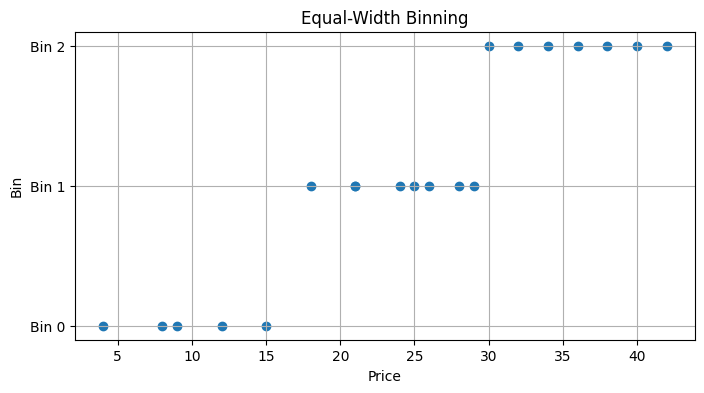

In [25]:
# 등간격 시각화
df_bin_plot = df_sklearn_bin.sort_values("Price").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.scatter(df_bin_plot["Price"], df_bin_plot["Equal_Width_SK"])
plt.title("Equal-Width Binning")
plt.xlabel("Price")
plt.ylabel("Bin")
plt.yticks([0, 1, 2], ["Bin 0", "Bin 1", "Bin 2"])
plt.grid(True)
plt.show()

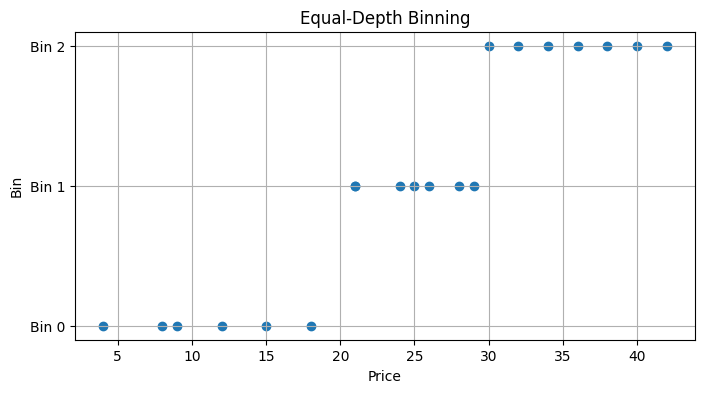

In [26]:
# 등빈도 시각화
plt.figure(figsize=(8, 4))
plt.scatter(df_bin_plot["Price"], df_bin_plot["Equal_Depth_SK"])
plt.title("Equal-Depth Binning")
plt.xlabel("Price")
plt.ylabel("Bin")
plt.yticks([0, 1, 2], ["Bin 0", "Bin 1", "Bin 2"])
plt.grid(True)
plt.show()

---

# Part 5. Data Exploration

데이터를 분석하거나 머신러닝 모델에 넣기 전에, 데이터 분석은 필수적임

### ■ 요약 통계 (Summary Statistics)
데이터의 전반적인 특성을 숫자 하나로 요약하여 보여줌
*   **범주형 속성 (Categorical attributes):** 빈도수(Frequency)와 최빈값(Mode)
*   **연속형 속성 (Continuous attributes):**
    *   **중심 위치 (Location):** 평균(Mean), 중앙값(Median)
    *   **퍼짐 정도 (Spread):** 분산(Variance), 범위(Range)
    *   **퍼센타일 (Percentiles):** 데이터를 크기순으로 나열했을 때 특정 백분율에 위치하는 값

### ■ 데이터 시각화 (Visualization)
숫자로만 보기 어려운 데이터의 패턴이나 이상치를 그래프로 한눈에 파악 가능
*   **히스토그램 (Histograms):** 단일 변수의 데이터 분포를 막대그래프로 나타내며, 구간(Bin)의 크기에 따라 모양이 달라짐
*   **박스 플롯 (Box Plots):** 0%(최소), 25%, 50%(중앙값), 75%, 100%(최대) 퍼센타일을 박스 형태로 시각화하며, 정상 범위를 벗어난 이상치(Outlier)를 식별하는 데 유용함
*   **산점도 (Scatter Plots):** 두 변수 간의 상관관계를 2차원 평면의 점으로 찍어 보여줌


In [27]:
import numpy as np
import pandas as pd
import seaborn as sns

# 외부 데이터셋
iris = sns.load_dataset('iris')

print("=== 데이터의 앞부분 확인 ===")
display(iris.head())


=== 데이터의 앞부분 확인 ===


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [28]:
# 요약 통계
print("\n 범주형 속성 통계 (종: species)")
# 빈도(Frequency)와 최빈값(Mode) 확인
frequency = iris['species'].value_counts()
mode_val = iris['species'].mode()
print(f"- 빈도수:\n{frequency}")
print(f"\n- 최빈값: \n{mode_val}")

print("\n 연속형 속성 통계 (꽃받침 길이: sepal_length)")
sepal_len = iris['sepal_length']

# 중심 위치 (Mean, Median)
print(f"- 평균(Mean): {sepal_len.mean():.2f}")
print(f"- 중앙값(Median): {sepal_len.median():.2f}")

# 퍼짐 정도 (Range, Variance)
range_val = sepal_len.max() - sepal_len.min()
variance_val = sepal_len.var()
print(f"- 범위(Range): {range_val:.2f} (최소 {sepal_len.min()} ~ 최대 {sepal_len.max()})")
print(f"- 분산(Variance): {variance_val:.2f}")

# 퍼센타일 (Percentiles)
percentiles = np.percentile(sepal_len, [25, 50, 75])
print(f"- 25% 퍼센타일: {percentiles[0]}")
print(f"- 50% 퍼센타일(중앙값과 동일): {percentiles[1]}")
print(f"- 75% 퍼센타일: {percentiles[2]}")


 범주형 속성 통계 (종: species)
- 빈도수:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

- 최빈값: 
0        setosa
1    versicolor
2     virginica
Name: species, dtype: object

 연속형 속성 통계 (꽃받침 길이: sepal_length)
- 평균(Mean): 5.84
- 중앙값(Median): 5.80
- 범위(Range): 3.60 (최소 4.3 ~ 최대 7.9)
- 분산(Variance): 0.69
- 25% 퍼센타일: 5.1
- 50% 퍼센타일(중앙값과 동일): 5.8
- 75% 퍼센타일: 6.4


---

In [29]:
import seaborn as sns
# Tip 데이터
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


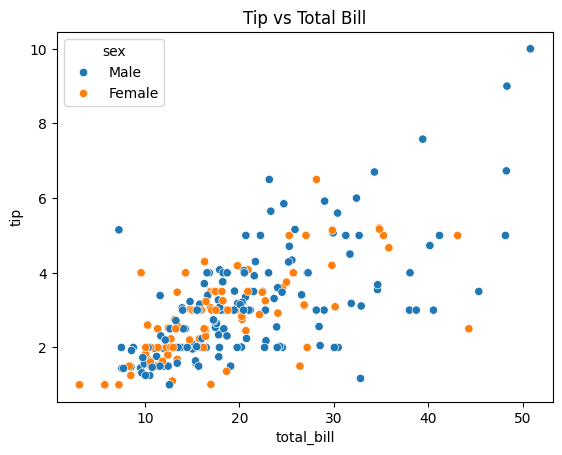

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex")
plt.title("Tip vs Total Bill")
plt.show()

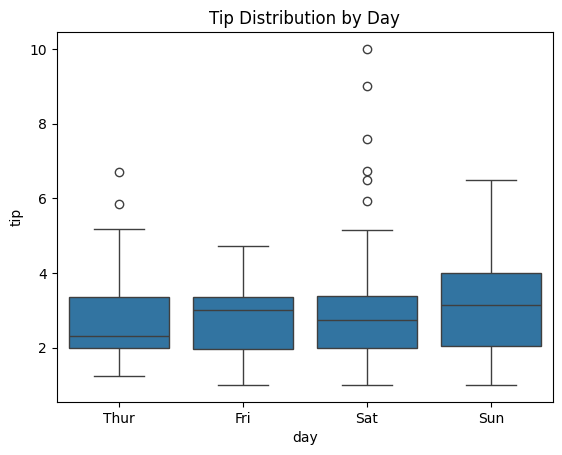

In [31]:
sns.boxplot(data=df, x="day", y="tip")
plt.title("Tip Distribution by Day")
plt.show()

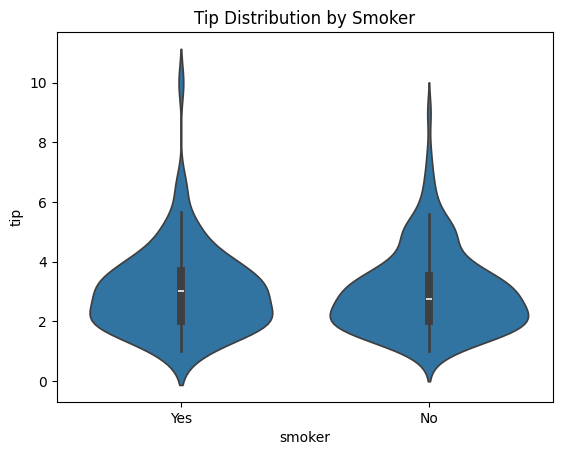

In [32]:
sns.violinplot(data=df, x="smoker", y="tip")
plt.title("Tip Distribution by Smoker")
plt.show()

---

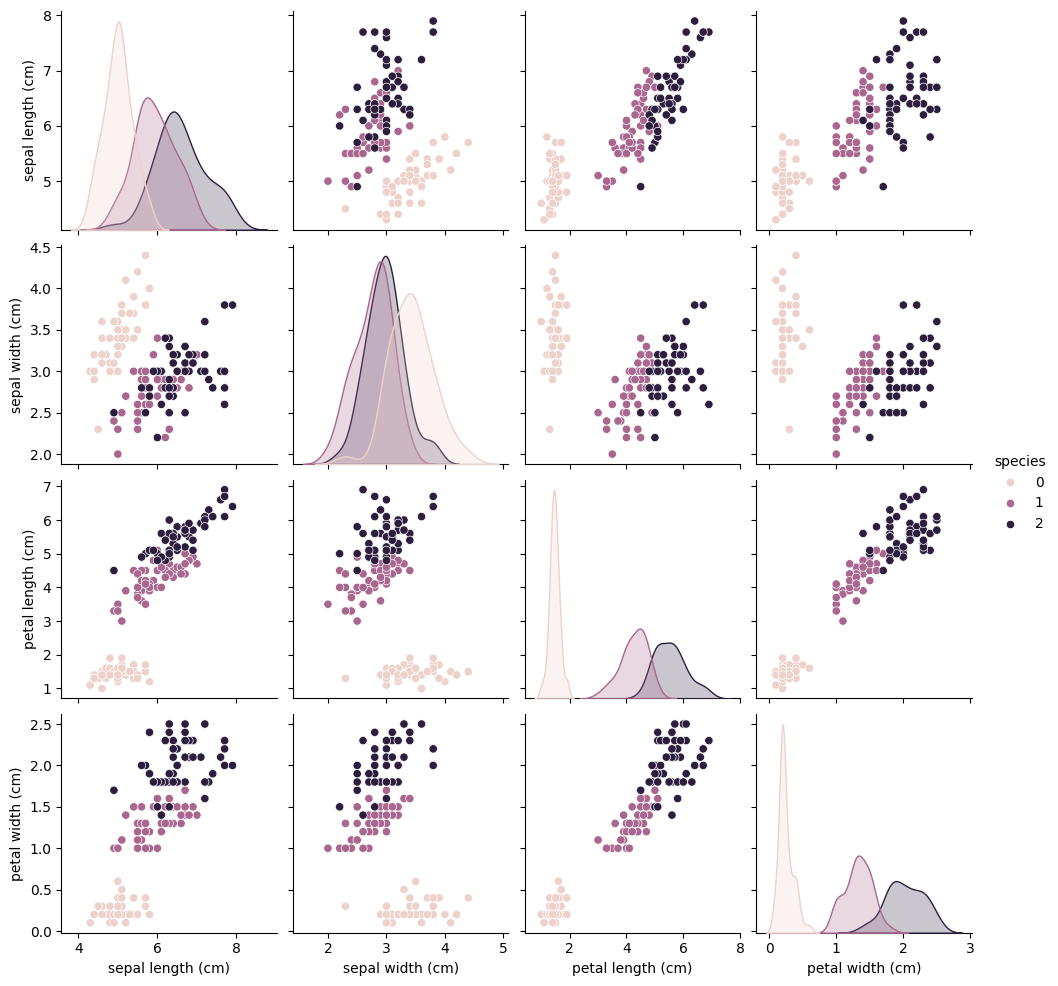

In [33]:
from sklearn.datasets import load_iris
import pandas as pd
# 외부 데이터
iris = load_iris()
# 각 feature마다 pair plot으로 표시 가능

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
sns.pairplot(df, hue="species")

---

In [34]:
# 외부 데이터
df = sns.load_dataset("titanic")

Text(0.5, 1.0, 'Survival Rate by Gender')

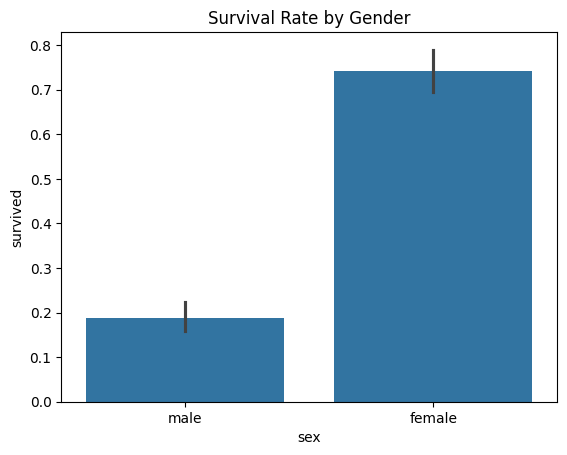

In [35]:
sns.barplot(data=df, x="sex", y="survived")
plt.title("Survival Rate by Gender")

<Axes: xlabel='class', ylabel='survived'>

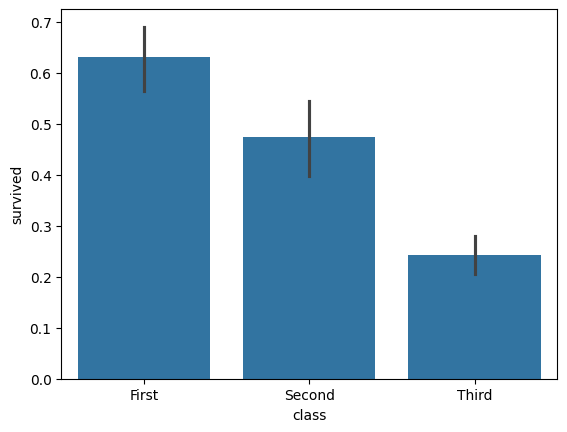

In [36]:
sns.barplot(data=df, x="class", y="survived")